In [1]:
import glob, os, sys, json
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
 class Experiment_Analyzer():
    def __init__(self, data_dir, json_fn=None):
        if not os.path.isdir(data_dir) and (data_dir.endswith('/') or data_dir.endswith('\\')):
            raise Exception('Data dir must be directory and written with trailing slash')
        
#         with open(json_fn, 'r') as g:
#             self.params = json.load(g)
        self.data_dir = os.path.normpath(data_dir)
        print(self.data_dir)
        self.loss_data = {'RMSD': 0, 'POTENTIAL': 0, 'SUM': 0, 'lambdas' : 0}
        
        self.model_name, self.latent_dim, self.rpt = self.data_dir.split(os.sep)[-3:]
        self.exp_name = f'{self.model_name}_{self.latent_dim}_{self.rpt}'
        print(self.exp_name)
        
    def retrieve_loss_from_npy(self):
        npy_fns = glob.glob(self.data_dir + '/*.npy')
        loss_keys = [key for key in self.loss_data]
        print(npy_fns)
        for key in loss_keys:
            npy_ind = [key in npy_fn for npy_fn in npy_fns].index(True)
            npy_data = np.load(npy_fns[npy_ind])
            self.loss_data[key] = npy_data
    
    def plot_losses(self, epoch_from=0, epoch_to=-1, y_lim=None, show_scaling=False, save_me=False, show_me=True):
        
        x = np.arange(self.loss_data['RMSD'].shape[-1])
        print( 1 in self.loss_data['lambdas'])
        
        plt.clf()
        fig, axs = plt.subplots(2, 2, figsize=(12, 9))
        
        begin_scaling_epoch = np.where(A.loss_data['lambdas'] != 0)[0][0]
        end_scaling_epoch = np.where(A.loss_data['lambdas'] == 1)[0][0]
        
        for Lname in ['RMSD', 'POTENTIAL', 'SUM', 'lambdas']:
            
            plt.clf()
            fig = plt.figure(constrained_layout=True, figsize=(12, 9))
            axs = fig.subplot_mosaic([['UpL', 'UpR'],['Bot', 'Bot']], gridspec_kw={'height_ratios':[2, 1]})
            axs['UpL'].set_title('Full Training', fontsize=18)
            axs['UpR'].set_title('Through Scaling', fontsize=18)
            axs['Bot'].set_title('After Scaling', fontsize=18)
            
            if Lname in ['RMSD', 'POTENTIAL', 'SUM']: #Loss Values
                for ax in axs:
                    axs[ax].legend(('Train', 'Test'))
            
                axs['UpL'].plot(x[epoch_from:epoch_to], self.loss_data[Lname][0, epoch_from: epoch_to])
                axs['UpL'].plot(x[epoch_from:epoch_to], self.loss_data[Lname][1, epoch_from: epoch_to])
                axs['UpL'].set_yscale('log')
                
                if epoch_to < 0 or begin_scaling_epoch < epoch_to:
                    axs['UpR'].plot(x[epoch_from: end_scaling_epoch], self.loss_data[Lname][0, epoch_from: end_scaling_epoch])
                    axs['UpR'].plot(x[epoch_from: end_scaling_epoch], self.loss_data[Lname][1, epoch_from: end_scaling_epoch])
                    axs['UpR'].set_yscale('log')
                    
                if epoch_from < end_scaling_epoch:
                    axs['Bot'].plot(x[end_scaling_epoch: epoch_to], self.loss_data[Lname][0, end_scaling_epoch: epoch_to])
                    axs['Bot'].plot(x[end_scaling_epoch: epoch_to], self.loss_data[Lname][1, end_scaling_epoch: epoch_to])
                    axs['Bot'].set_yscale('log')
            else: #Lambdas
                axs['UpL'].plot(x[epoch_from:epoch_to], self.loss_data[Lname][epoch_from: epoch_to])
                if epoch_to < 0 or begin_scaling_epoch < epoch_to:
                    axs['UpR'].plot(x[epoch_from: end_scaling_epoch], self.loss_data[Lname][epoch_from: end_scaling_epoch])
                if epoch_from < end_scaling_epoch:
                    axs['Bot'].plot(x[end_scaling_epoch: epoch_to], self.loss_data[Lname][end_scaling_epoch: epoch_to])
                
            
            
                        
            fig.suptitle(Lname, fontsize=22)
            #Scaling Bars:
            axs['UpR'].axvline(begin_scaling_epoch, color='r', linestyle='dashed')
            axs['UpR'].axvline(end_scaling_epoch, color='r', linestyle='dashed')
            
            if Lname == 'RMSD':
                axs['UpR'].axhline(0.15, color='b', linestyle='dashed')
            elif Lname == 'POTENTIAL':
                axs['Bot'].axhline(1e-3, color='b', linestyle='dashed')
            elif Lname == 'lambdas':
                axs['UpR'].axhline(1, color='b', linestyle='dashed')
            
#             if save_me:
#                 save_name = f'images/{self.exp_name}_{Lname}.png'
#                 plt.savefig(save_name, dpi=600)        
            if show_me:
                plt.show()

In [7]:
data_dirs = sorted(glob.glob('/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/*4_latents/rpt_*/'))
for data_dir in data_dirs:
    print(data_dir)

/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_0/
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_2/
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_0/
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_2/
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_0/
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_2/
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/34_latents/rpt_0/
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/34_latents/rpt_2/
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_0/
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_2/


/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_0
modelL_04_latents_rpt_0
['/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_0/modelL04_POTENTIAL.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_0/modelL04_SUMM.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_0/modelL04_lambdas.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_0/modelL04_RMSD.npy']
True


<Figure size 640x480 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

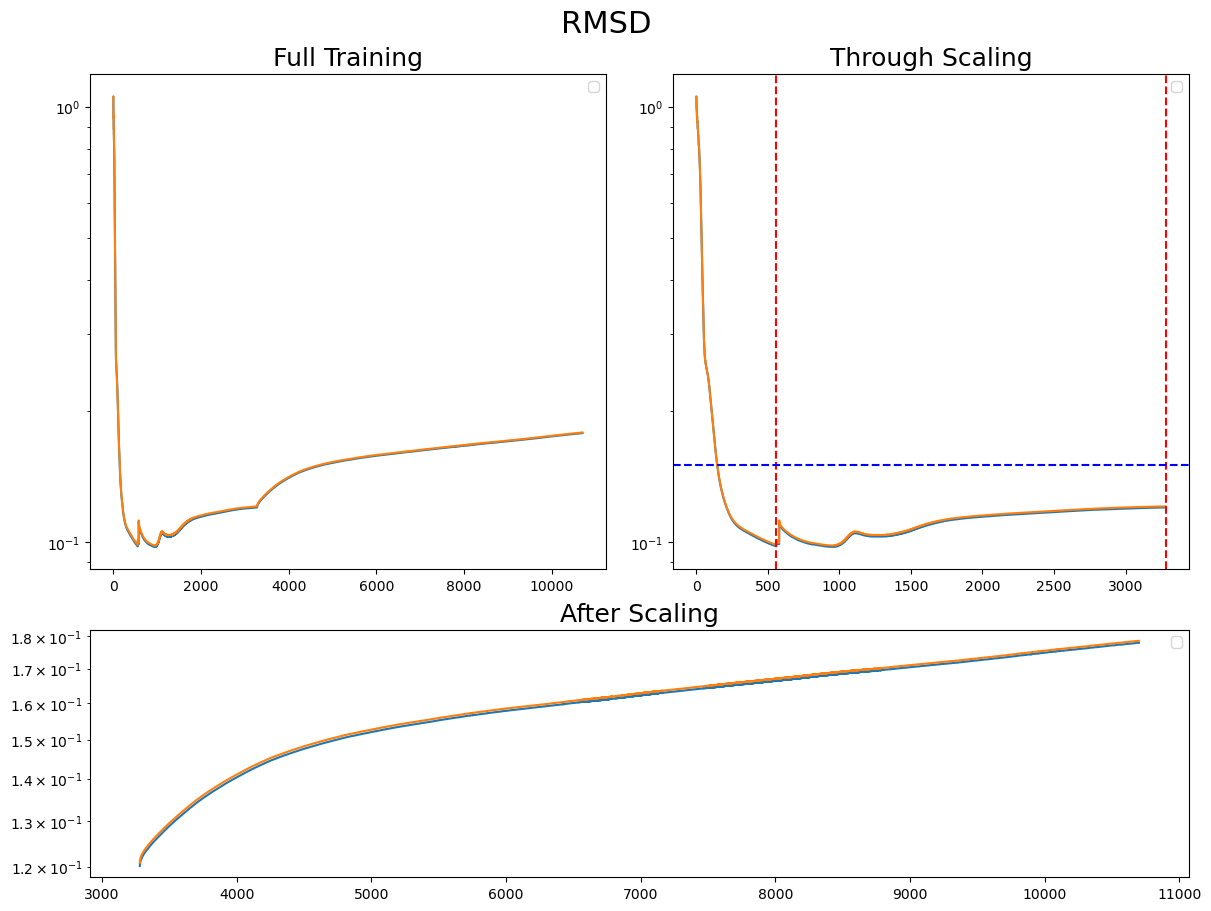

<Figure size 640x480 with 0 Axes>

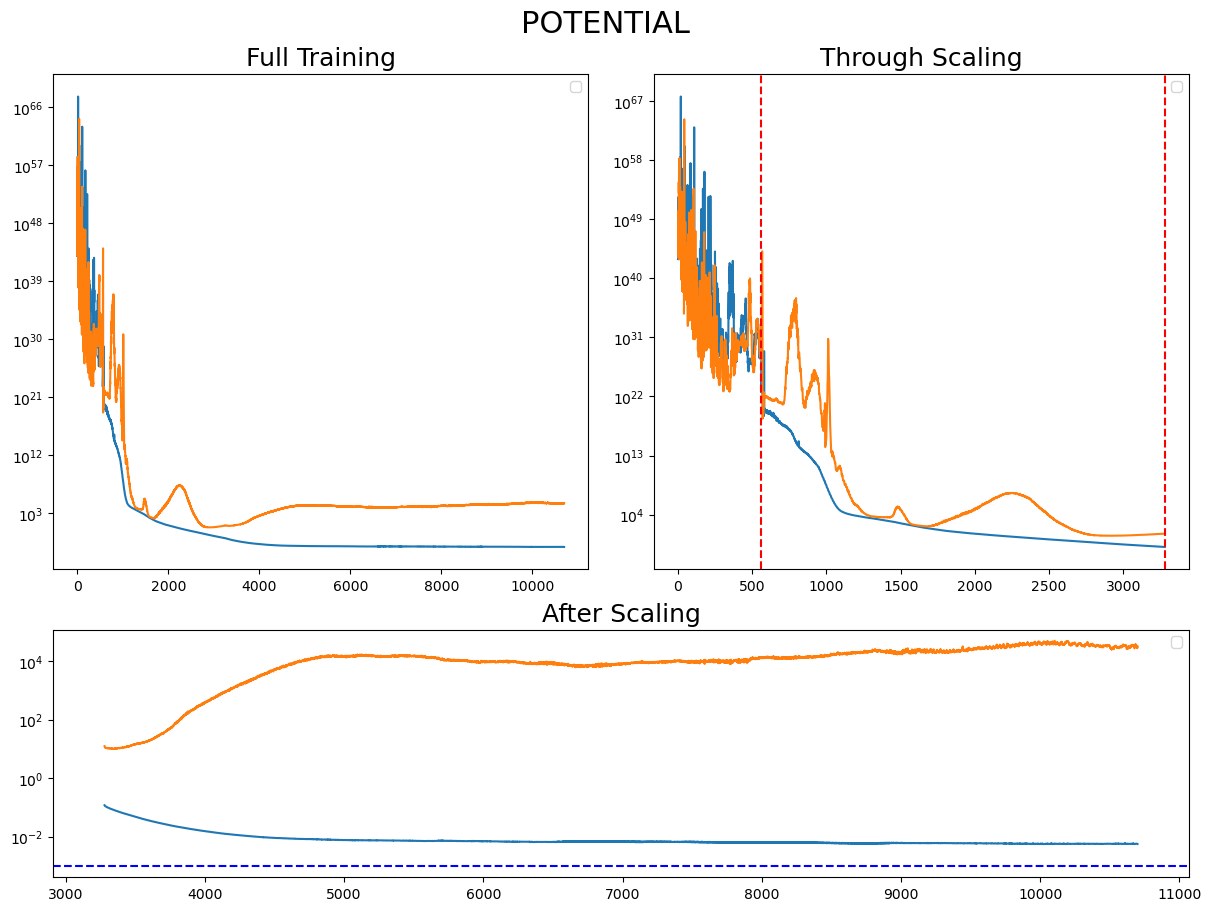

<Figure size 640x480 with 0 Axes>

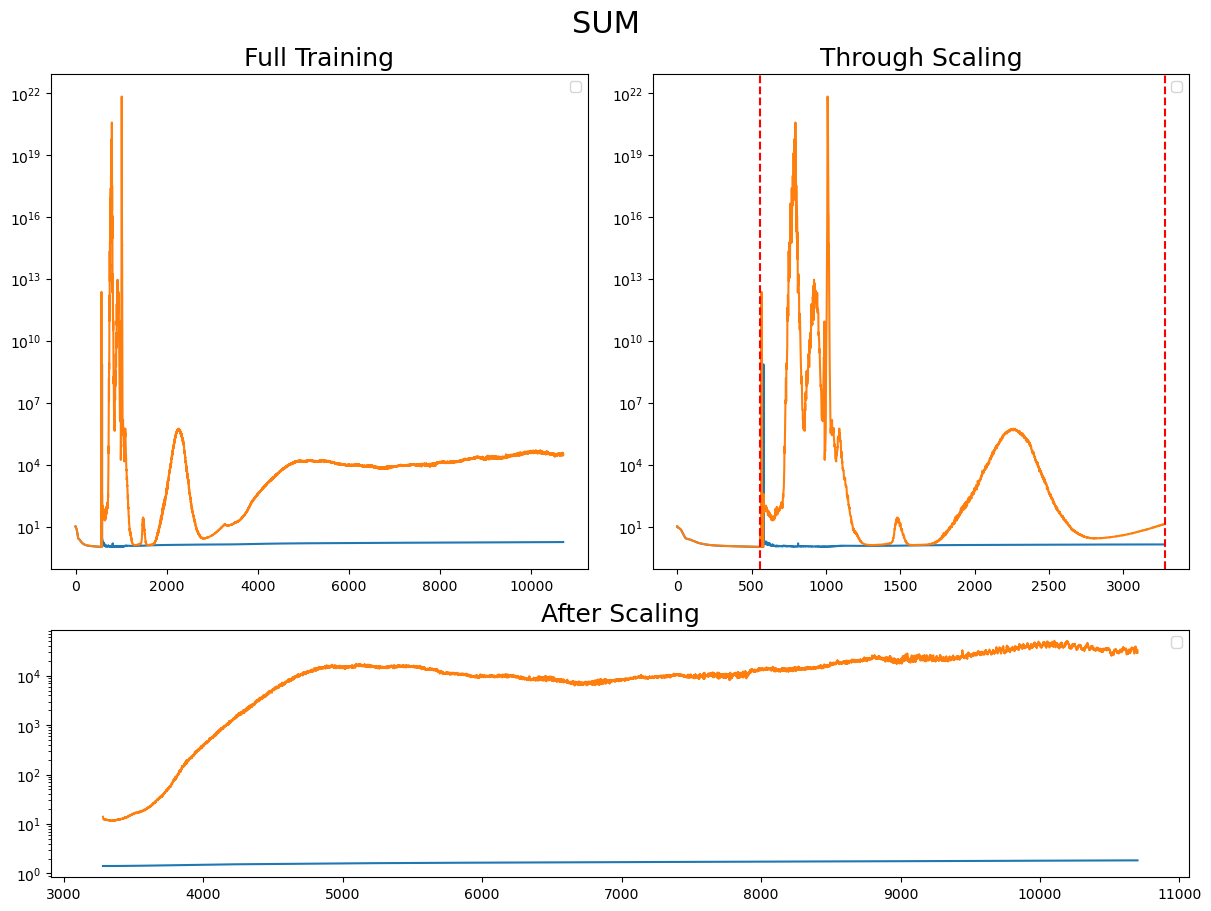

<Figure size 640x480 with 0 Axes>

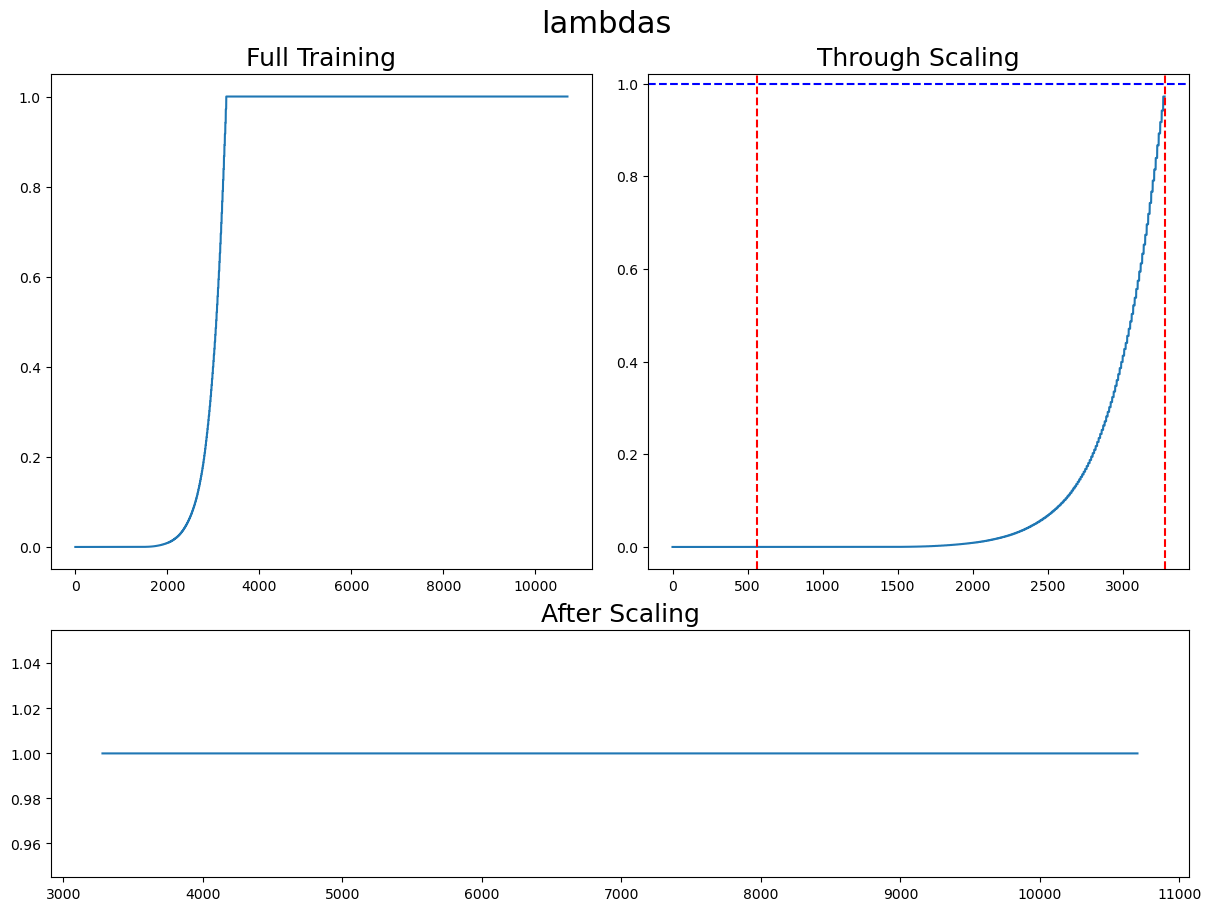

/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_2
modelL_04_latents_rpt_2
['/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_2/modelL04_POTENTIAL.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_2/modelL04_SUMM.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_2/modelL04_lambdas.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/04_latents/rpt_2/modelL04_RMSD.npy']
True


<Figure size 640x480 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

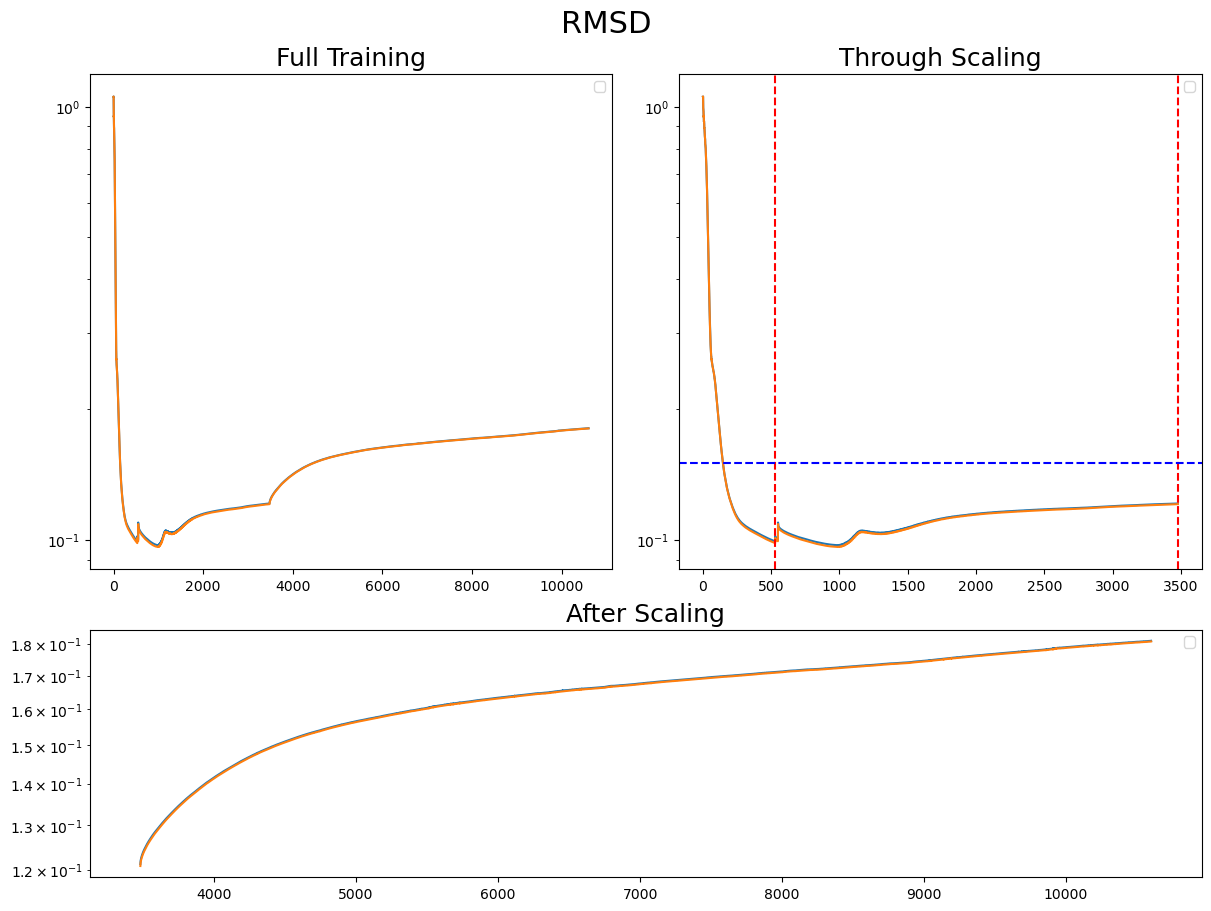

<Figure size 640x480 with 0 Axes>

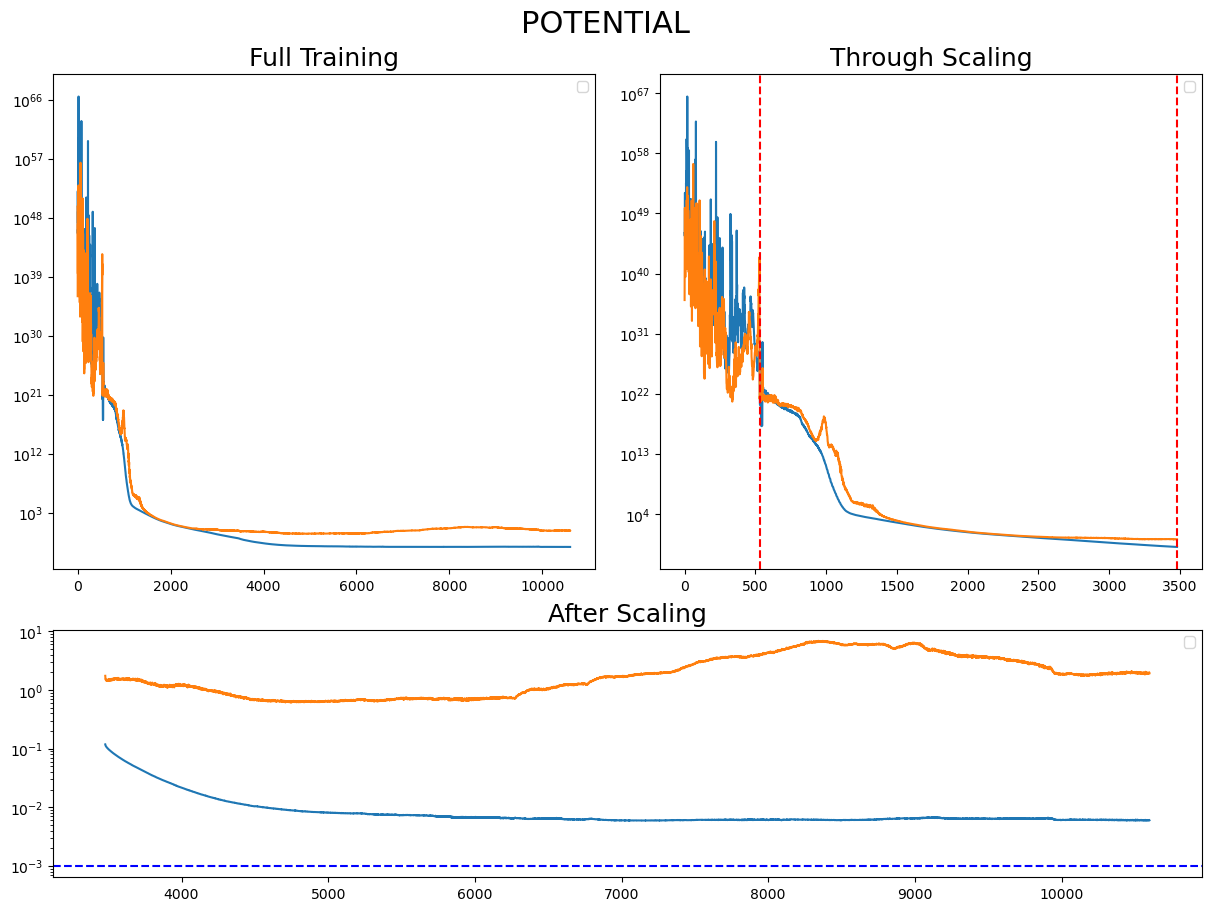

<Figure size 640x480 with 0 Axes>

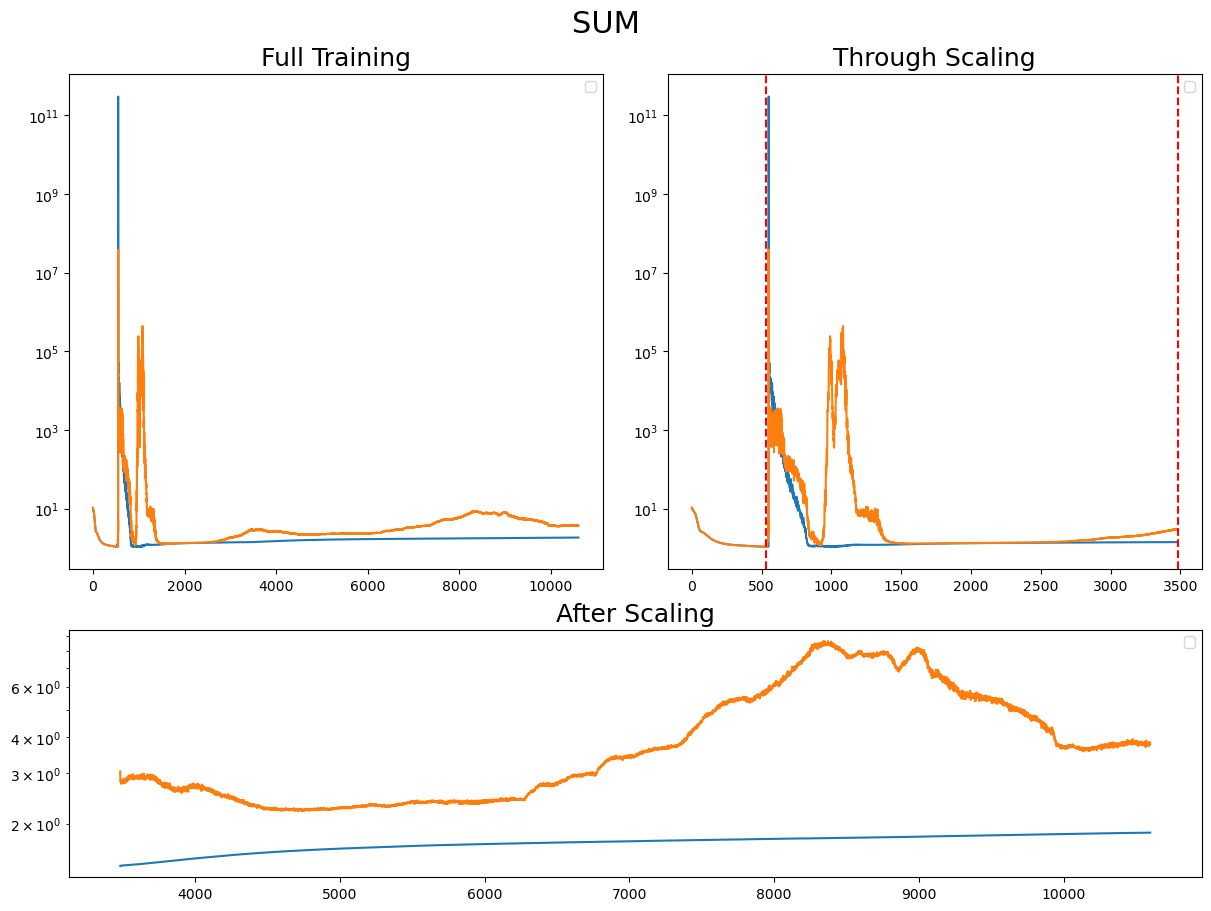

<Figure size 640x480 with 0 Axes>

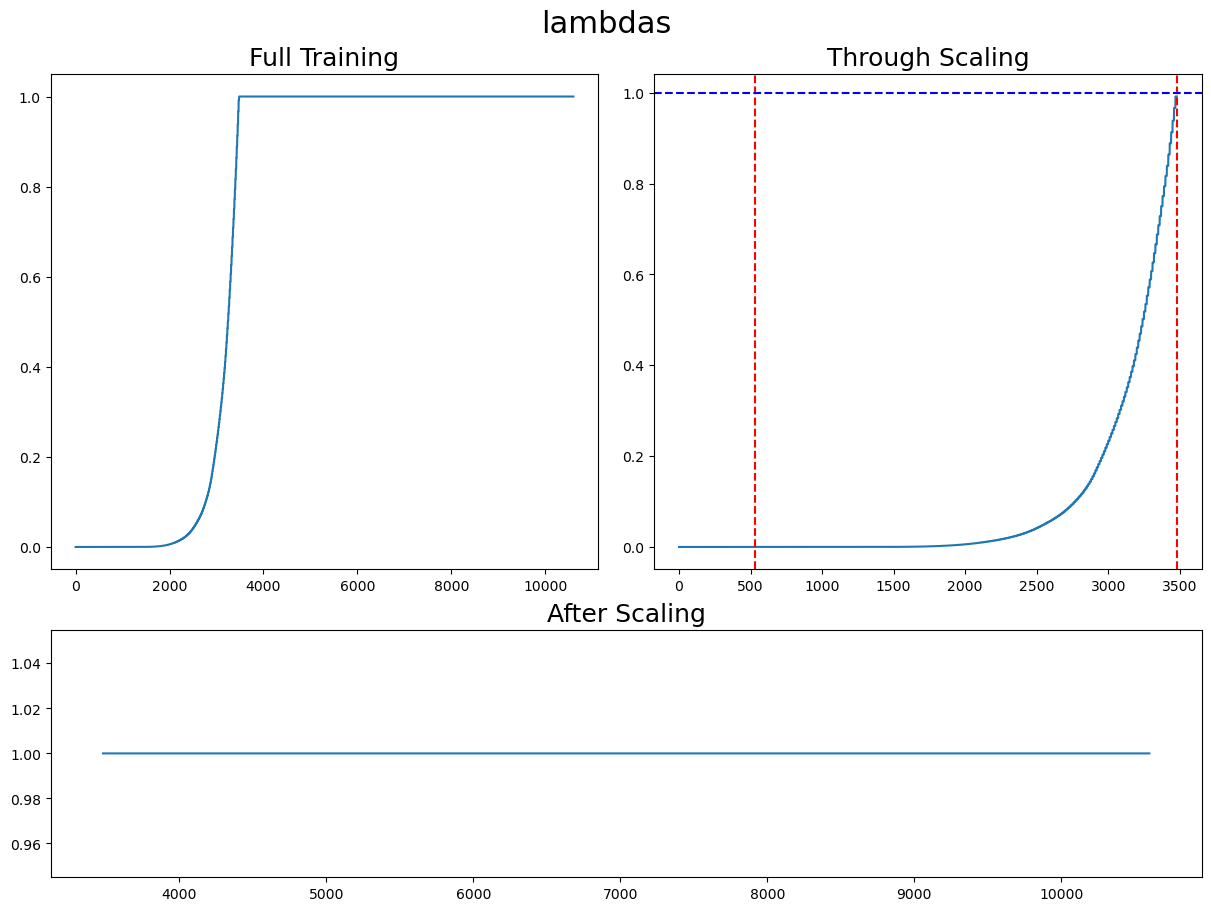

/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_0
modelL_14_latents_rpt_0
['/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_0/modelL14_POTENTIAL.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_0/modelL14_SUMM.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_0/modelL14_RMSD.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_0/modelL14_lambdas.npy']
False
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_2
modelL_14_latents_rpt_2
['/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_2/modelL14_POTENTIAL.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_2/modelL14_SUMM.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_2/modelL14_RMSD.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/14_latents/rpt_2/modelL14_lambdas.npy']


<Figure size 640x480 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

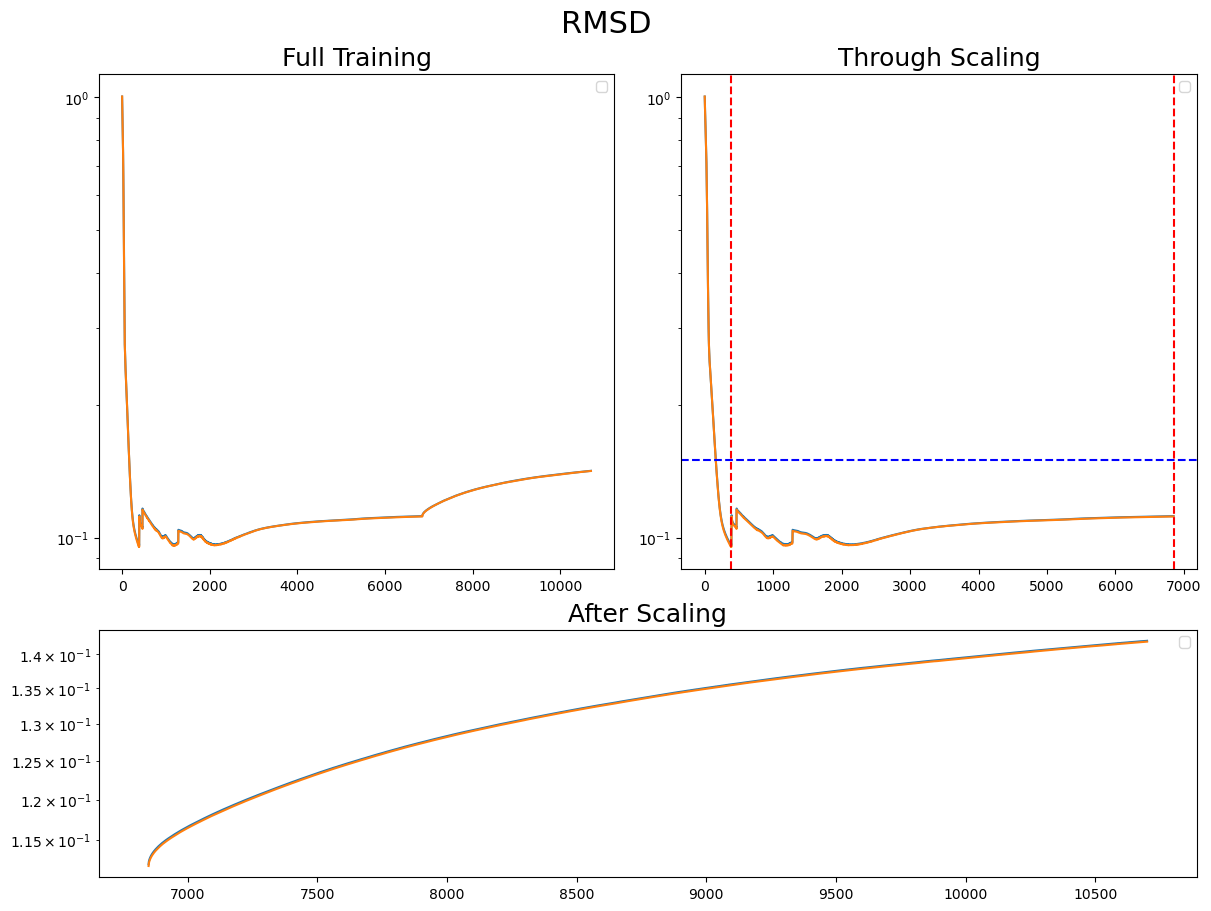

<Figure size 640x480 with 0 Axes>

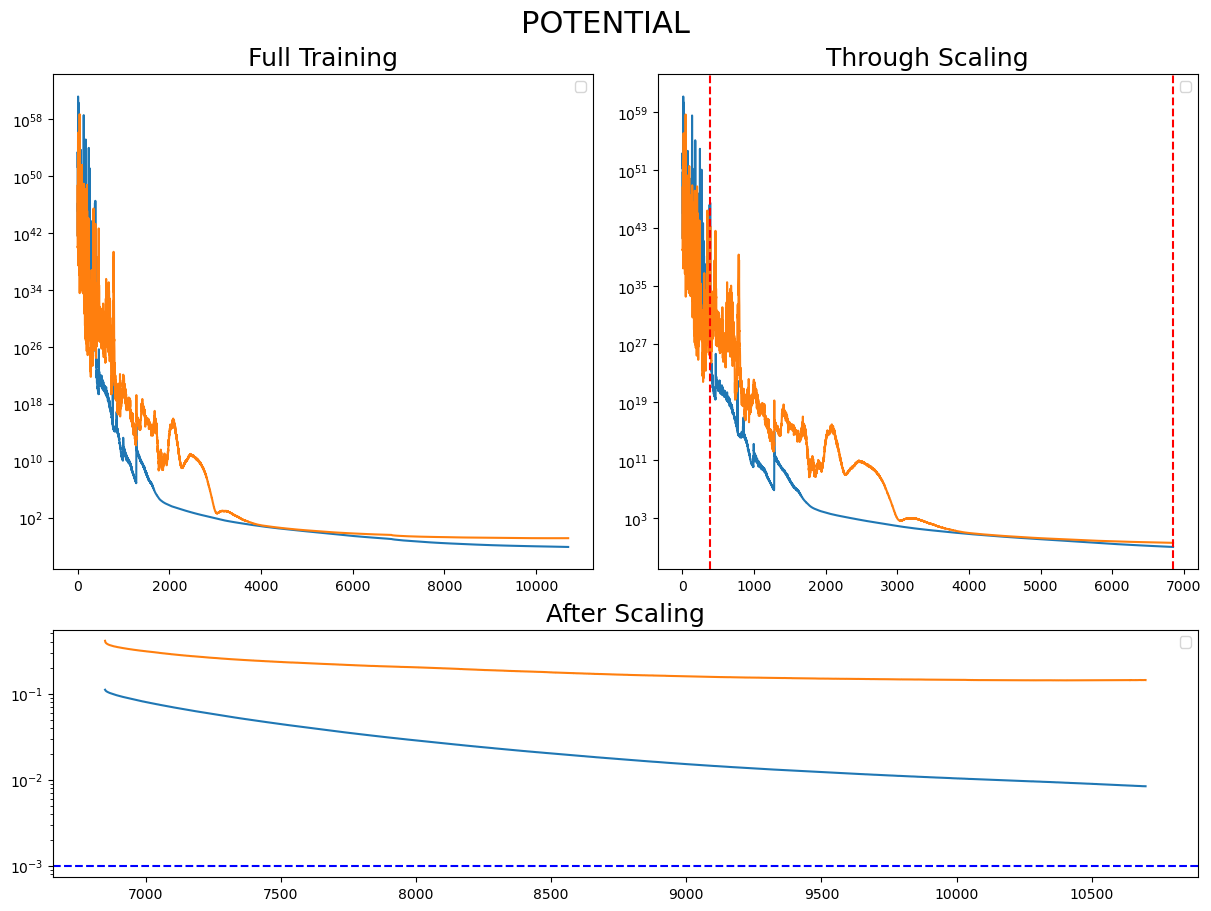

<Figure size 640x480 with 0 Axes>

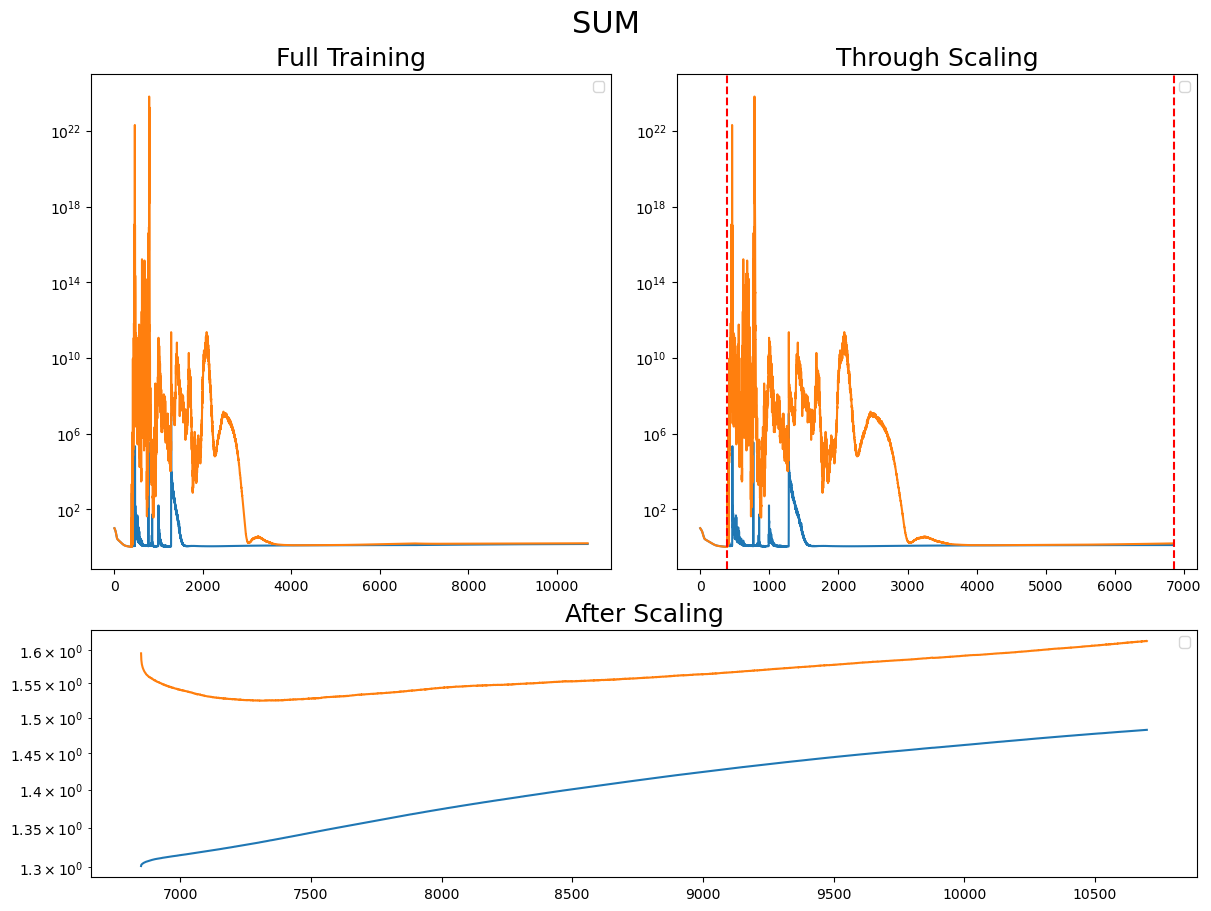

<Figure size 640x480 with 0 Axes>

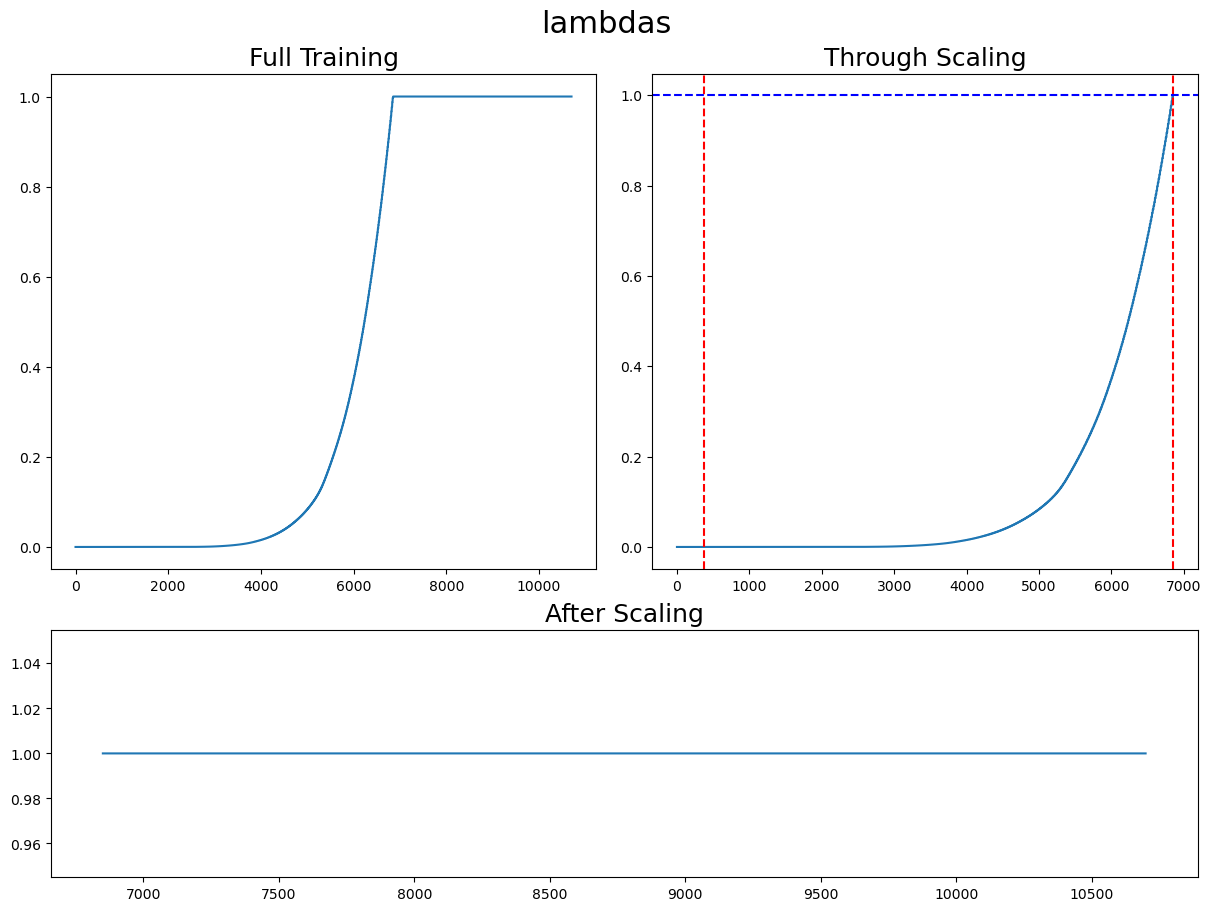

/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_0
modelL_24_latents_rpt_0
['/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_0/modelL24_POTENTIAL.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_0/modelL24_RMSD.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_0/modelL24_SUMM.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_0/modelL24_lambdas.npy']
False
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_2
modelL_24_latents_rpt_2
['/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_2/modelL24_POTENTIAL.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_2/modelL24_RMSD.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_2/modelL24_SUMM.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/24_latents/rpt_2/modelL24_lambdas.npy']


<Figure size 640x480 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

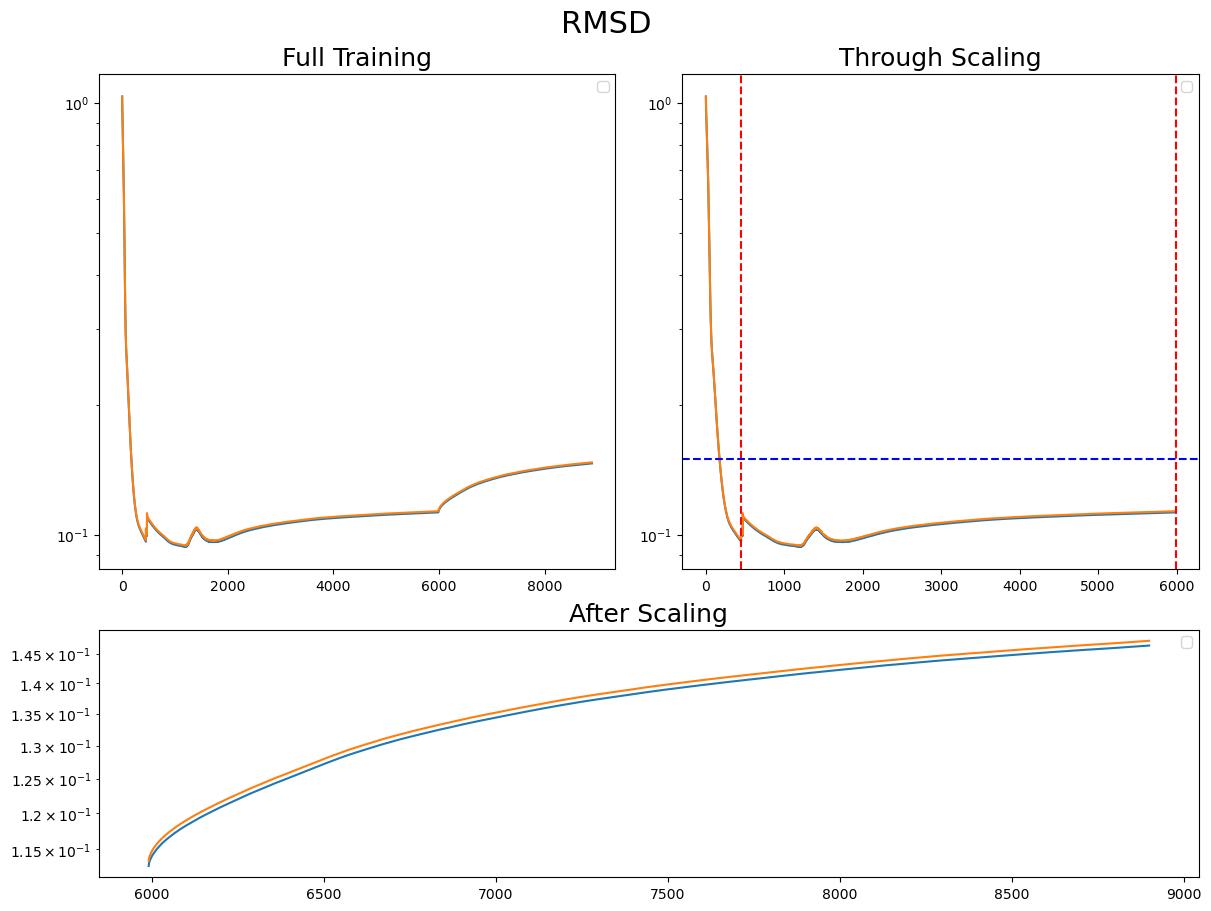

<Figure size 640x480 with 0 Axes>

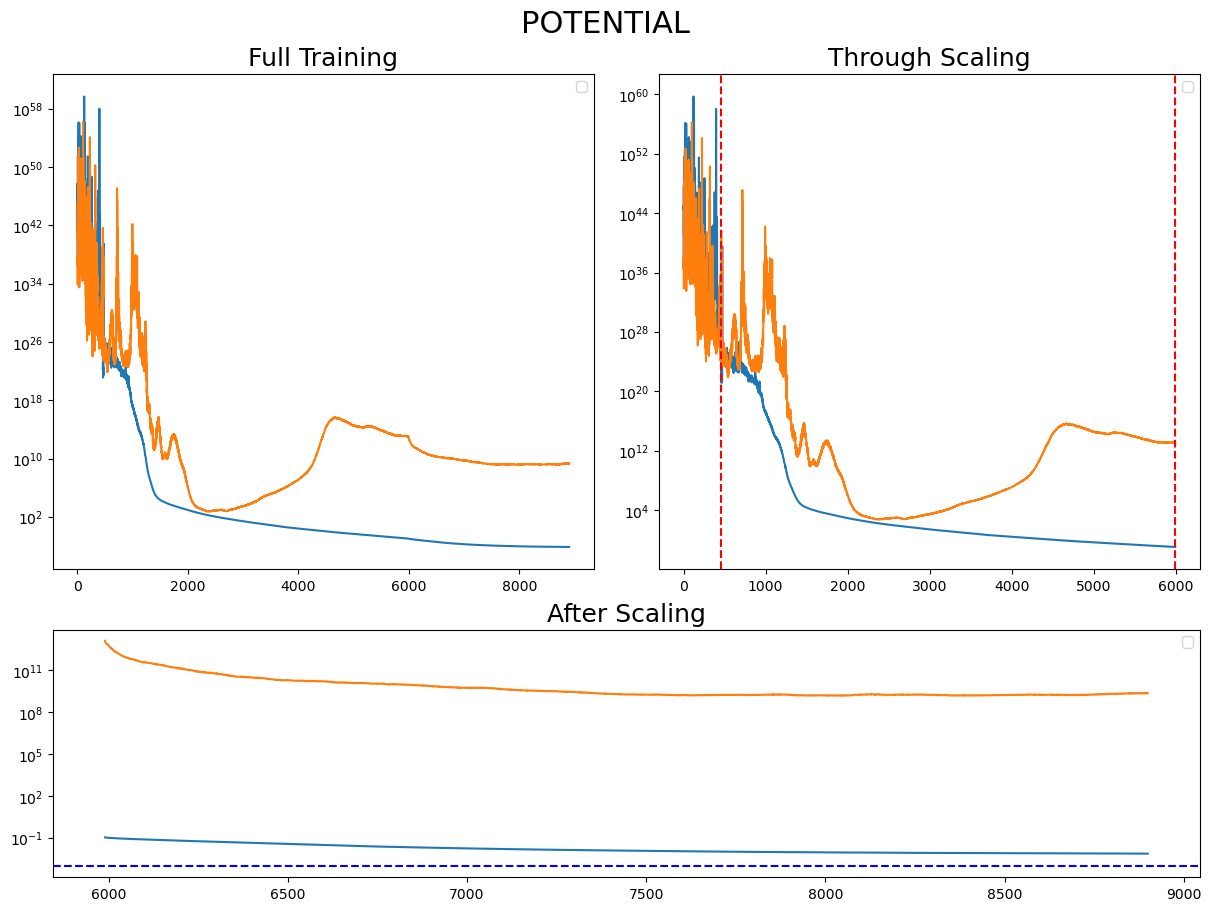

<Figure size 640x480 with 0 Axes>

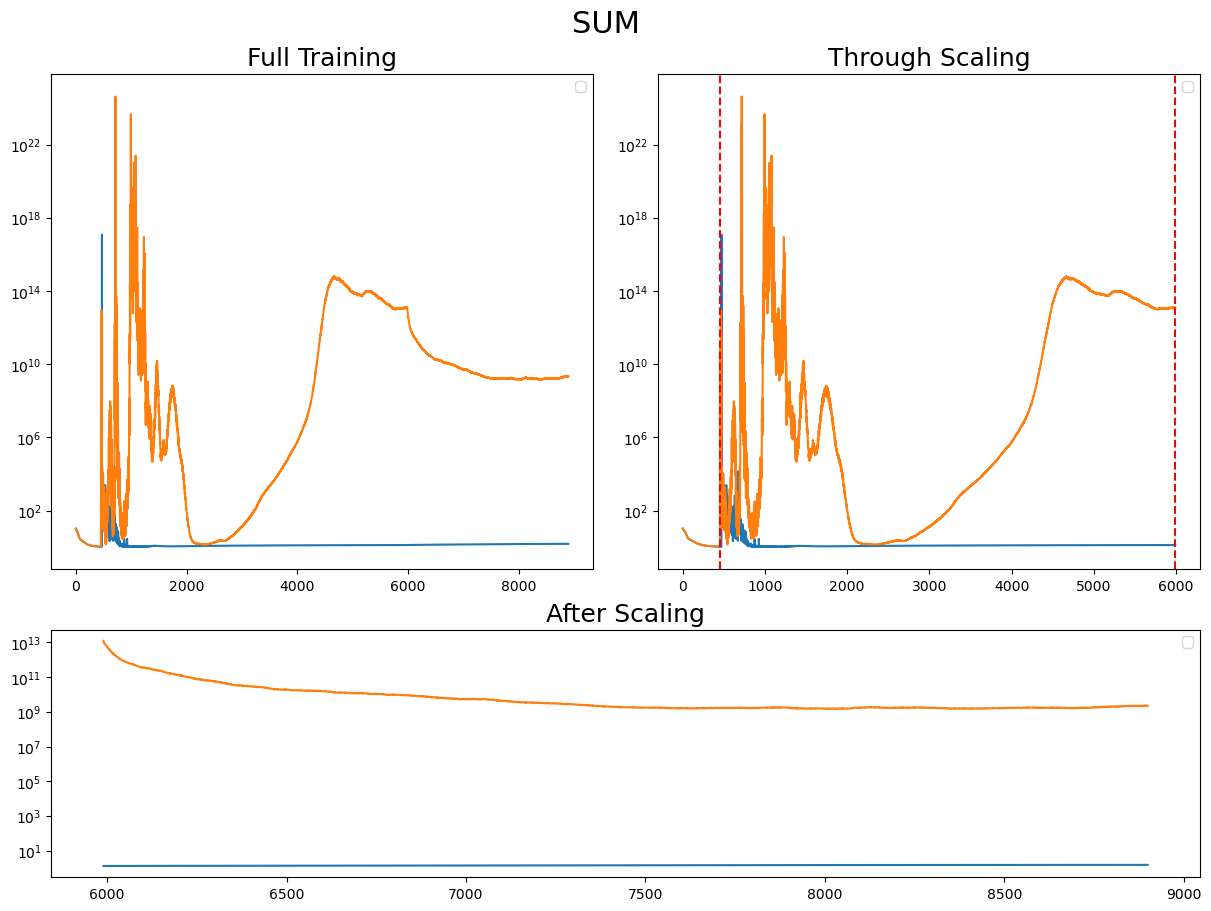

<Figure size 640x480 with 0 Axes>

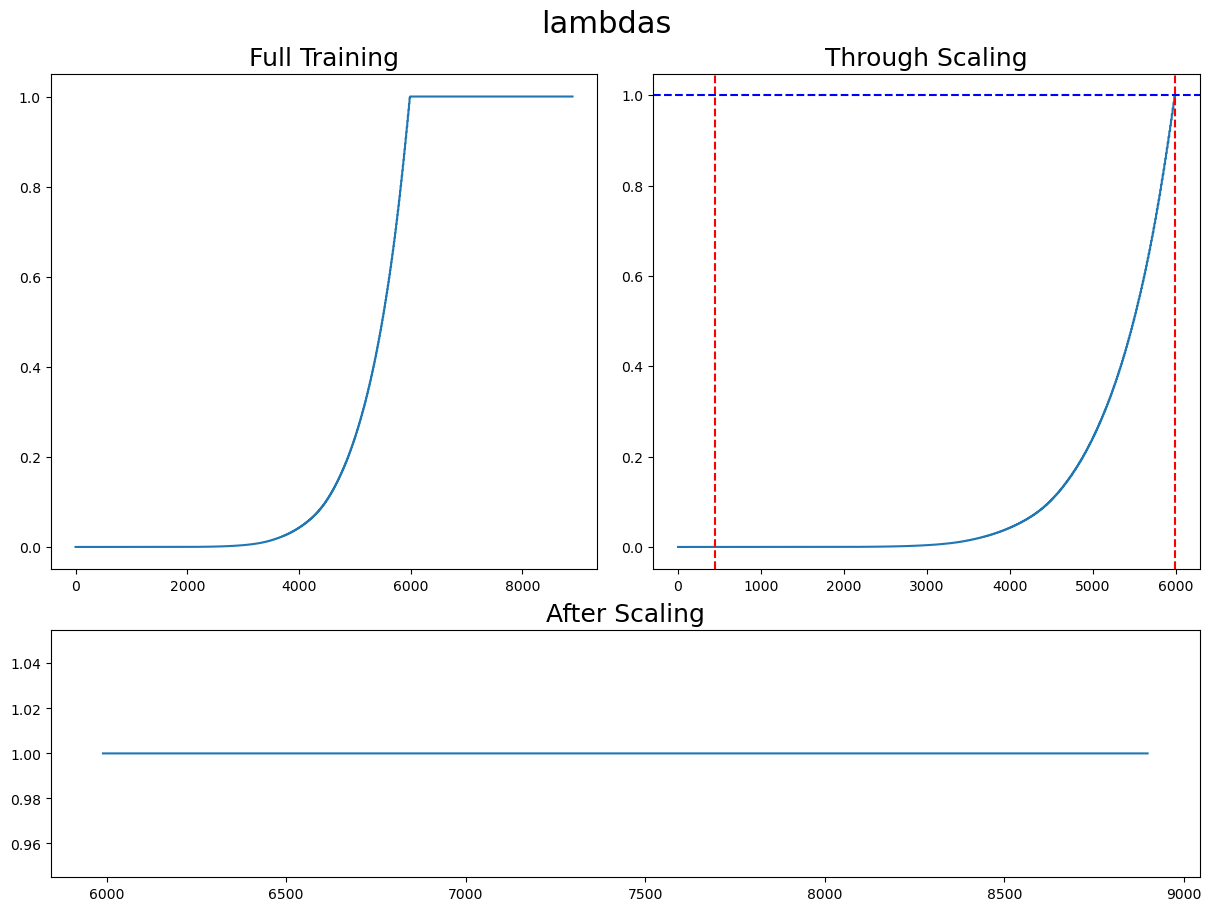

/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/34_latents/rpt_2
modelL_34_latents_rpt_2
['/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/34_latents/rpt_2/modelL34_SUMM.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/34_latents/rpt_2/modelL34_lambdas.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/34_latents/rpt_2/modelL34_POTENTIAL.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/34_latents/rpt_2/modelL34_RMSD.npy']
False
/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_0
modelL_44_latents_rpt_0
['/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_0/modelL44_lambdas.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_0/modelL44_SUMM.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_0/modelL44_POTENTIAL.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_0/modelL44_RMSD.npy']


<Figure size 640x480 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

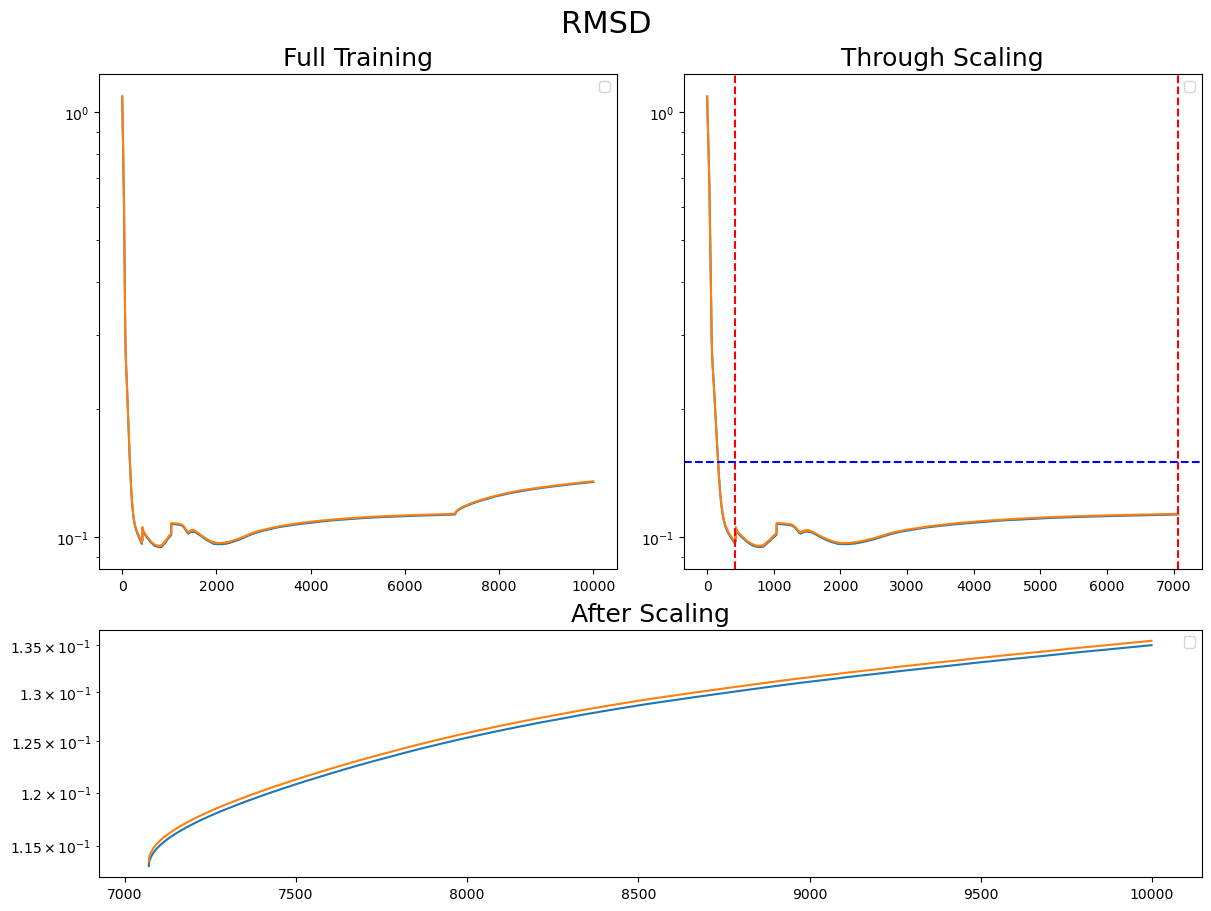

<Figure size 640x480 with 0 Axes>

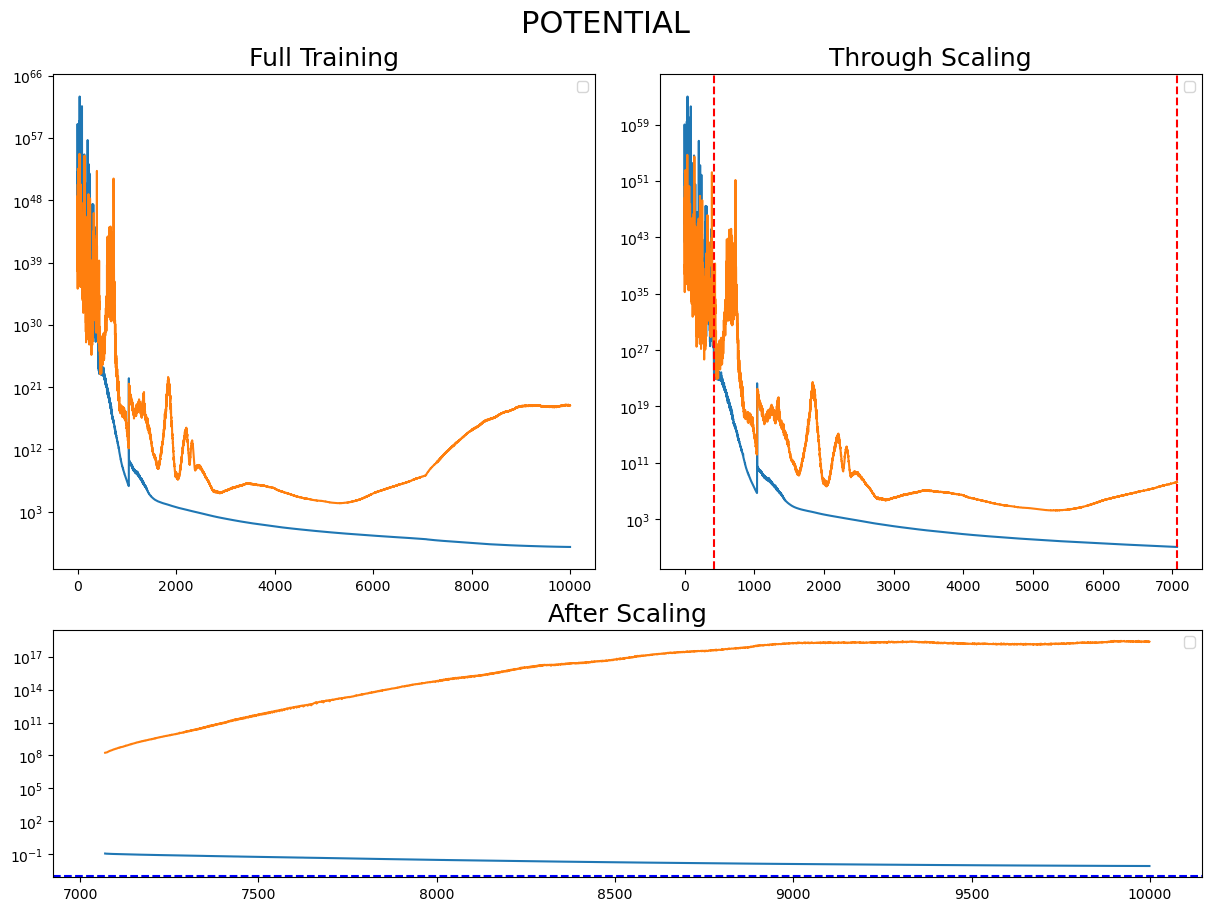

<Figure size 640x480 with 0 Axes>

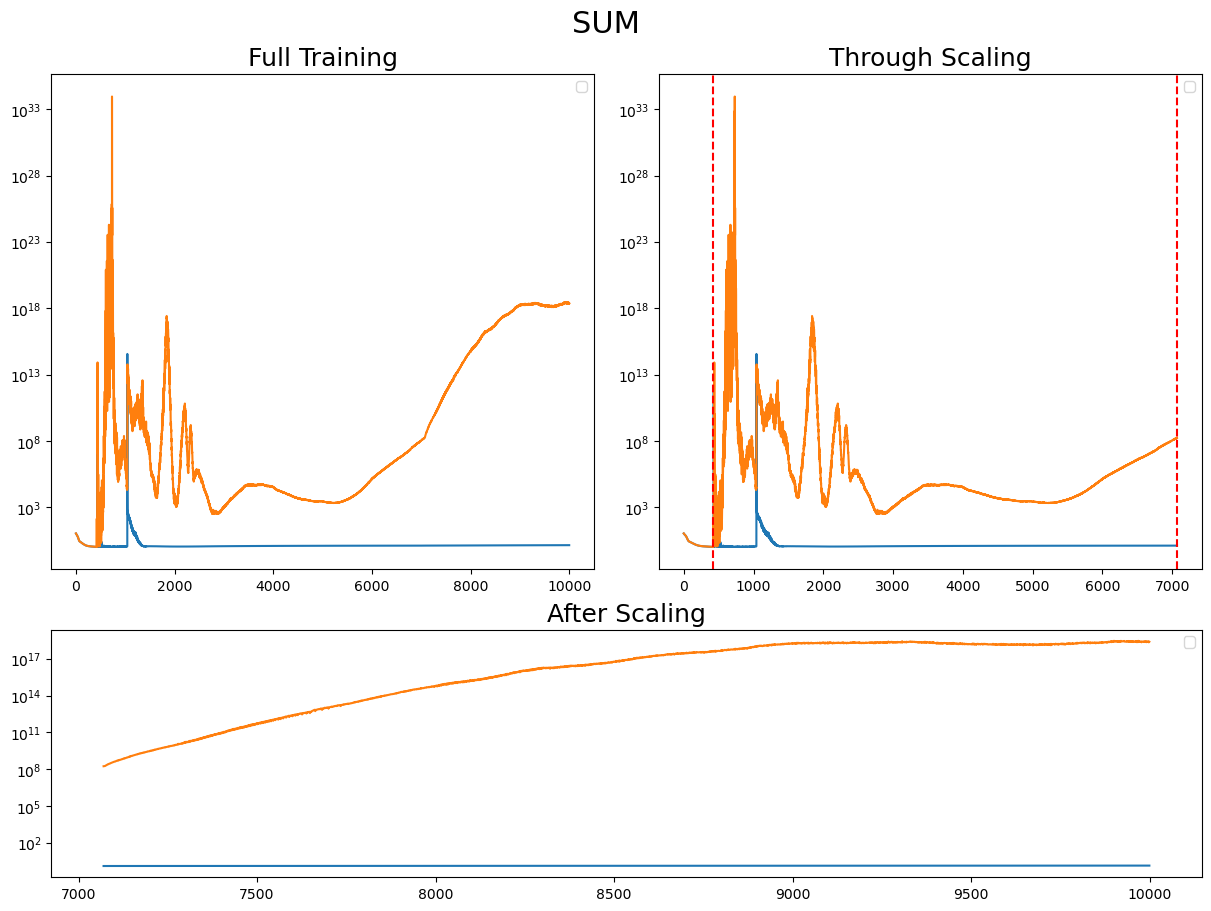

<Figure size 640x480 with 0 Axes>

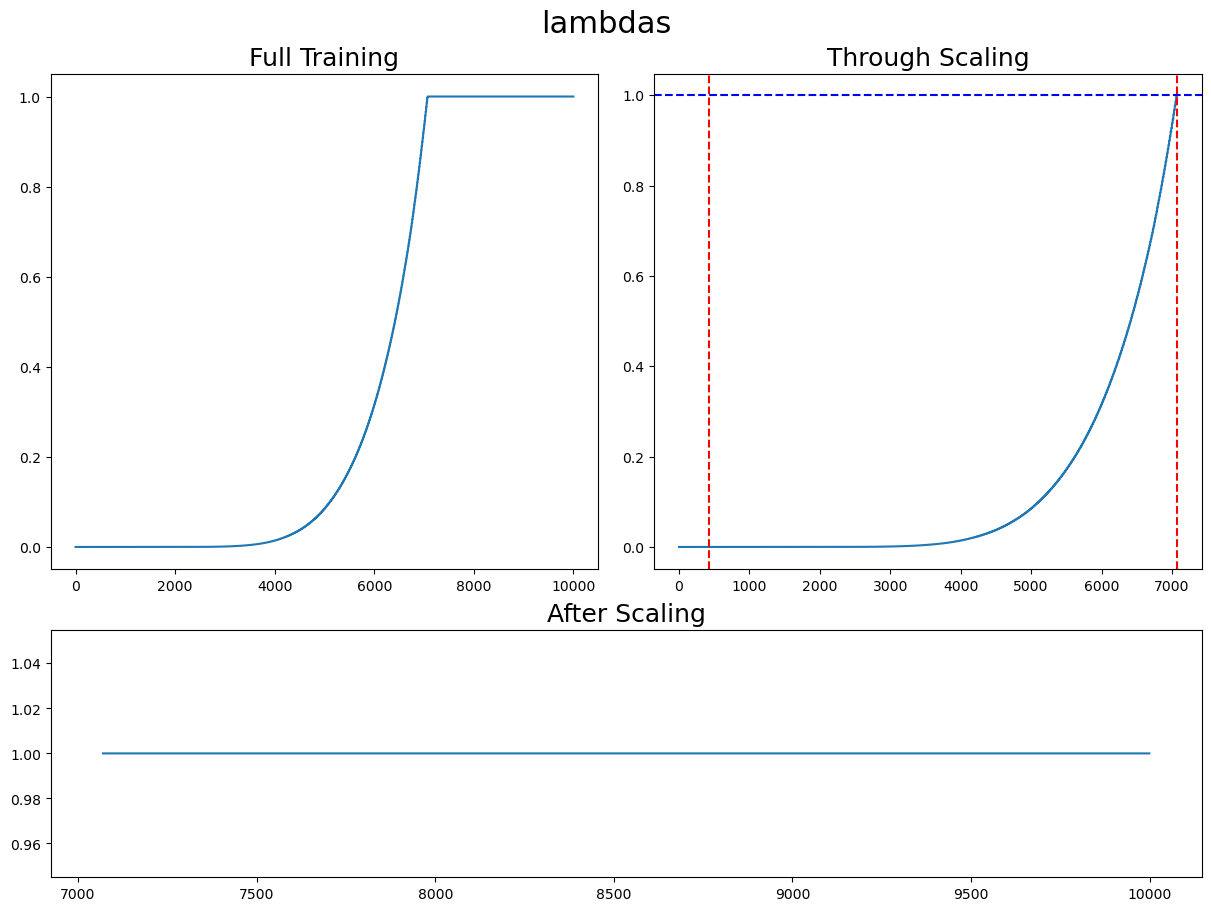

/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_2
modelL_44_latents_rpt_2
['/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_2/modelL44_lambdas.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_2/modelL44_SUMM.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_2/modelL44_POTENTIAL.npy', '/media/volume/sdb/VAE/VAE_0.0.4/Dropout_DecaAlanine/modelL/44_latents/rpt_2/modelL44_RMSD.npy']
False


<Figure size 640x480 with 0 Axes>

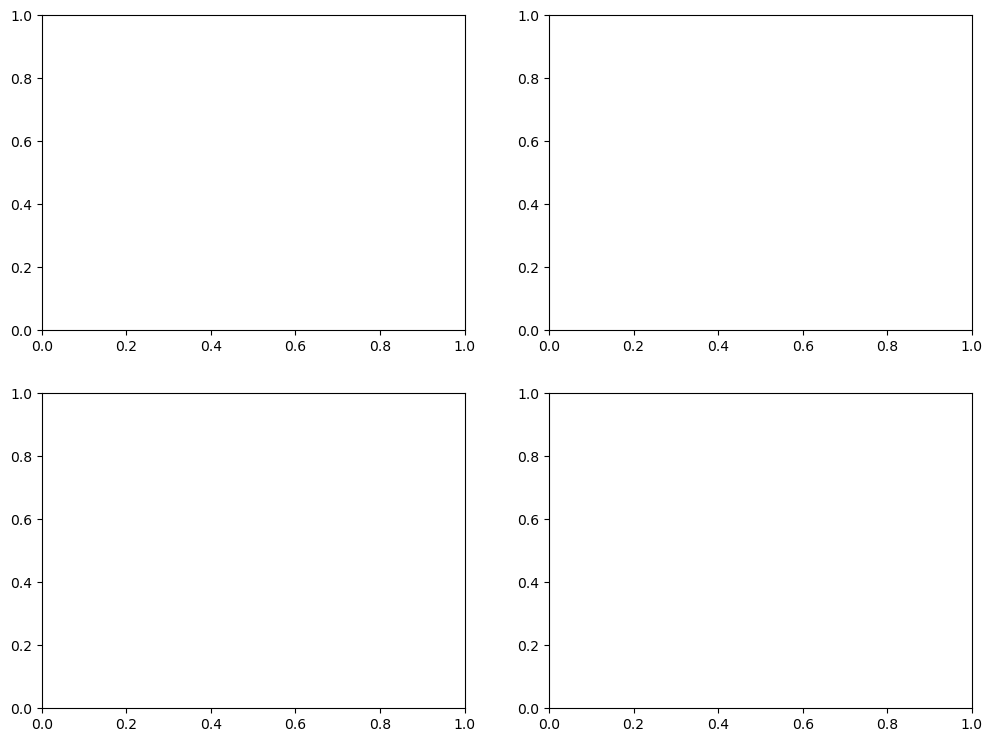

In [8]:
for data_dir in data_dirs:
    A = Experiment_Analyzer(data_dir)
    A.retrieve_loss_from_npy()
    try:
        A.plot_losses(show_scaling=False, save_me=False, show_me=True)
    except:
        pass
#     try:
#         A.plot_losses(show_scaling=False, save_me=False, show_me=True)
#     except:
#         pass
#         A = Experiment_Analyzer(data_dir.replace('rpt_3', 'rpt_2'))
#         A.retrieve_loss_from_npy()
#         A.plot_losses(show_scaling=False, save_me=True, show_me=False)